<a href="https://colab.research.google.com/github/massimilianogasparini-author/creative-loop-dynamics/blob/main/creative_loop_dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

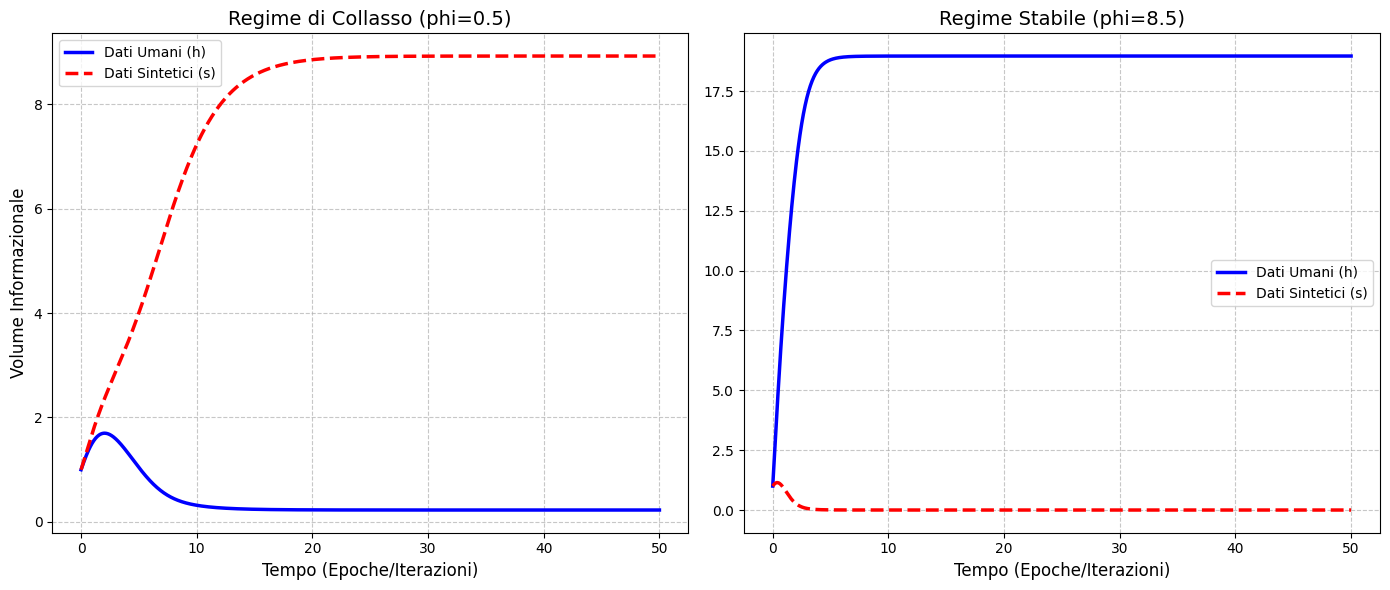

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Definizione dei parametri per la simulazione (Modello h-s)
alpha = 0.5    # Tasso di crescita/recupero dati umani
beta = 0.3     # Interferenza dei dati sintetici
gamma = 0.4    # Tasso di apprendimento del modello (overfitting)
lambd_ = 0.2   # Soppressione sintetica dovuta a dati umani
K = 10.0       # Capacità massima di recupero dati umani
K_s = 10.0     # Capacità rappresentazionale massima del modello

# Definizione del sistema di equazioni differenziali
def creative_loop_system(y, t, phi):
    h, s = y
    s_safe = max(s, 1e-6) # Protezione per il logaritmo
    dh_dt = alpha * h * (1 - h / K) - beta * h * s + phi
    ds_dt = gamma * s * np.log(K_s / s_safe) - lambd_ * s * h
    return [dh_dt, ds_dt]

# Impostazioni temporali (50 iterazioni)
t = np.linspace(0, 50, 1000)
y0 = [1.0, 1.0] # Condizioni iniziali

# Simulazione dei due scenari principali
phi_collapse = 0.5 # Sotto la soglia critica
phi_stable = 8.5   # Sopra la soglia critica (Creative Loop)

sol_collapse = odeint(creative_loop_system, y0, t, args=(phi_collapse,))
sol_stable = odeint(creative_loop_system, y0, t, args=(phi_stable,))

# Generazione dei grafici
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico Regime di Collasso
ax1.plot(t, sol_collapse[:, 0], 'b-', label='Dati Umani (h)', linewidth=2.5)
ax1.plot(t, sol_collapse[:, 1], 'r--', label='Dati Sintetici (s)', linewidth=2.5)
ax1.set_title(f'Regime di Collasso (phi={phi_collapse})', fontsize=14)
ax1.set_xlabel('Tempo (Epoche/Iterazioni)', fontsize=12)
ax1.set_ylabel('Volume Informazionale', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Grafico Regime Stabile
ax2.plot(t, sol_stable[:, 0], 'b-', label='Dati Umani (h)', linewidth=2.5)
ax2.plot(t, sol_stable[:, 1], 'r--', label='Dati Sintetici (s)', linewidth=2.5)
ax2.set_title(f'Regime Stabile (phi={phi_stable})', fontsize=14)
ax2.set_xlabel('Tempo (Epoche/Iterazioni)', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()